In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [10]:
df=pd.read_csv('world_cup.csv')
df.head(10)

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64
5,2002,"Korea Republic, Japan",32,Brazil,Germany,Ronaldo - 8,2705337,42271,64
6,1998,France,32,France,Brazil,Davor Šuker - 6,2903477,45367,64
7,1994,United States,24,Brazil,Italy,"Hristo Stoichkov, Oleg Salenko - 6",3587538,68991,52
8,1990,Italy,24,West Germany,Argentina,Salvatore Schillaci - 6,2516215,48389,52
9,1986,Mexico,24,Argentina,West Germany,Gary Lineker - 6,2394031,46039,52


In [3]:
df.columns

Index(['Year', 'Host', 'Teams', 'Champion', 'Runner-Up', 'TopScorrer',
       'Attendance', 'AttendanceAvg', 'Matches'],
      dtype='object')

In [4]:
df.describe()

,Year,Teams,Attendance,AttendanceAvg,Matches
count,22.000000,22.000000,2.200000e+01,22.000000,22.000000
mean,1978.909091,22.363636,2.002201e+06,42728.545455,43.818182
std,27.738419,7.454915,1.101740e+06,12136.930791,17.632860
min,1930.000000,13.000000,3.630000e+05,20872.000000,17.000000
25%,1959.000000,16.000000,9.311905e+05,34749.000000,32.000000
50%,1980.000000,20.000000,1.987738e+06,46705.000000,45.000000
75%,2001.000000,32.000000,2.999695e+06,49527.250000,64.000000
max,2022.000000,32.000000,3.587538e+06,68991.000000,64.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           22 non-null     int64 
 1   Host           22 non-null     object
 2   Teams          22 non-null     int64 
 3   Champion       22 non-null     object
 4   Runner-Up      22 non-null     object
 5   TopScorrer     22 non-null     object
 6   Attendance     22 non-null     int64 
 7   AttendanceAvg  22 non-null     int64 
 8   Matches        22 non-null     int64 
dtypes: int64(5), object(4)
memory usage: 1.7+ KB


In [6]:
df.shape

(22, 9)

In [7]:
df.isnull().sum()

Year             0
Host             0
Teams            0
Champion         0
Runner-Up        0
TopScorrer       0
Attendance       0
AttendanceAvg    0
Matches          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

Tournament History Analytics

In [12]:
# Total FIFA World Cups held
total_world_cups = df['Year'].nunique()
print("Total FIFA World Cups:", total_world_cups)

Total FIFA World Cups: 22


In [ ]:
#countries hosted the World Cup
host_counts = df['Host'].value_counts().reset_index(name='Count')
host_counts

,Host,Count
0,Brazil,2
1,Mexico,2
2,Germany,2
3,Italy,2
4,France,2
5,Qatar,1
6,South Africa,1
7,"Korea Republic, Japan",1
8,Russia,1
9,United States,1


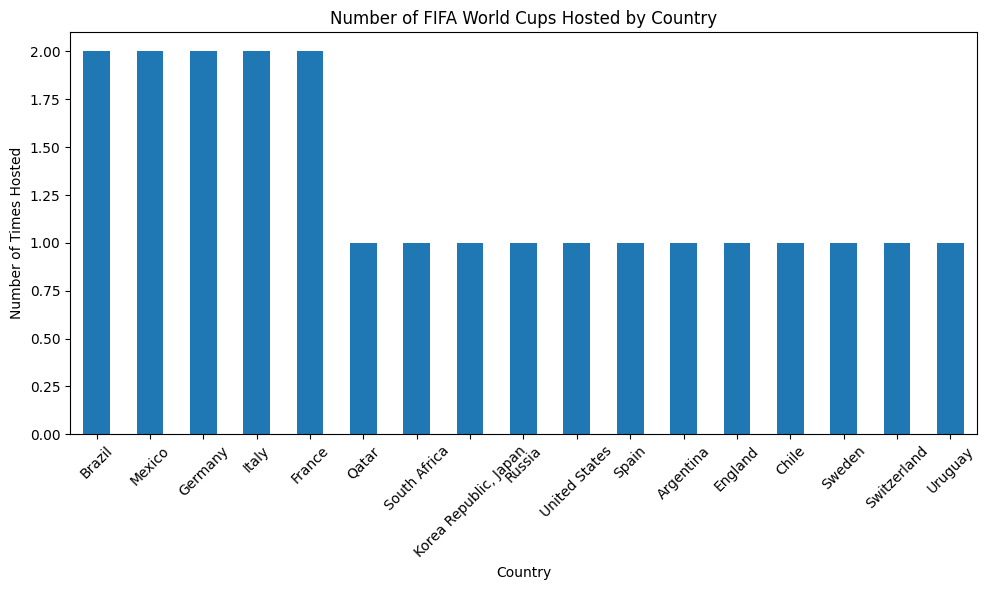

In [26]:


host_counts = df['Host'].value_counts()

plt.figure(figsize=(10, 6))
host_counts.plot(kind='bar')
plt.title('Number of FIFA World Cups Hosted by Country')
plt.xlabel('Country')
plt.ylabel('Number of Times Hosted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
 # country that hosted the most World Cups

most_hosts = df['Host'].value_counts().idxmax()
host_count = df['Host'].value_counts().max()

print(f"{most_hosts} has hosted the World Cup {host_count} times.")


Brazil has hosted the World Cup 2 times.


Text(0, 0.5, 'ylabel')

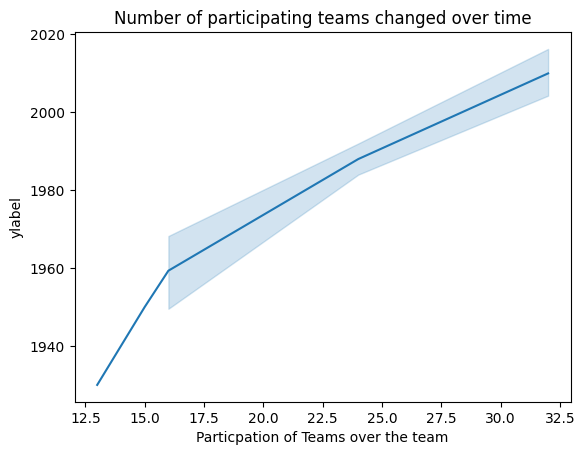

In [31]:
sns.lineplot(data=df,x='Teams',y='Year')
plt.title('Number of participating teams changed over time')
plt.xlabel('Particpation of Teams over the team')
plt.ylabel('ylabel')

Text(0, 0.5, 'Year')

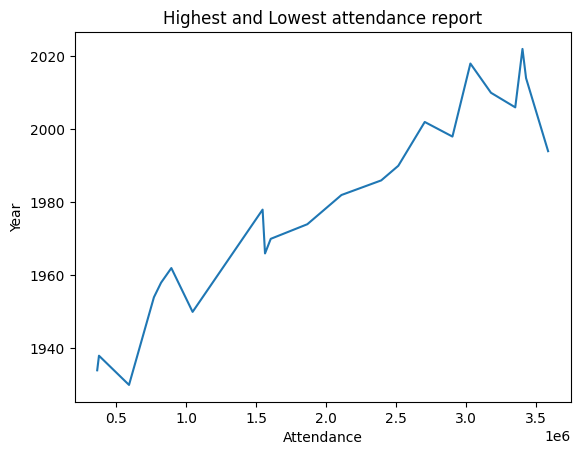

In [36]:
# World Cup had the highest attendance and Lowest attendance 
sns.lineplot(data=df,x='Attendance',y='Year')
plt.title('Highest and Lowest attendance report')
plt.xlabel('Attendance')
plt.ylabel('Year')

In [37]:
df.columns

Index(['Year', 'Host', 'Teams', 'Champion', 'Runner-Up', 'TopScorrer',
       'Attendance', 'AttendanceAvg', 'Matches'],
      dtype='object')

In [52]:
avg_attendance_per_touranement=df.groupby('Year')['Attendance'].mean().sort_values(ascending=False).reset_index(name='Avg')
avg_attendance_per_touranement.head(10)

,Year,Avg
0,1994,3587538.0
1,2014,3429873.0
2,2022,3404252.0
3,2006,3352605.0
4,2010,3178856.0
5,2018,3031768.0
6,1998,2903477.0
7,2002,2705337.0
8,1990,2516215.0
9,1986,2394031.0


C:\Users\Dell\AppData\Local\Temp\ipykernel_15576\2906648725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5,x='Year',y='Avg',palette='viridis')


Text(0, 0.5, 'Avg ')

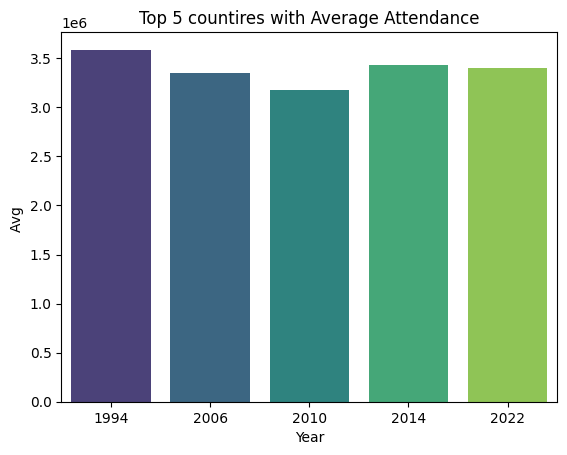

In [53]:
top5=avg_attendance_per_touranement.head(5)
sns.barplot(data=top5,x='Year',y='Avg',palette='viridis')
plt.title('Top 5 countires with Average Attendance')
plt.xlabel('Year')
plt.ylabel('Avg ')

In [ ]:
# World Cup had the most matches played


,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
